# Importando as libs e o DataSet

In [67]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [68]:
# Loading dataset
path_projeto = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
path_data = os.path.join(path_projeto, "data", "train.csv")
df = pd.read_csv(path_data)

# Entendendo os dados

Vamos uitlizar o info para ter uma visão geral dos dados. Esse metodo nos mostra o shape do nosso dataset, o nome de cada coluna, o tipo de cada coluna e também a quantiddade de valores não nulos em cada coluna.

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Agoras vamos utilizar o método describe para analisar alguns indices estatisticos das colunas.

In [70]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Vamos alterar o nome de cada coluna para que todas as letras possam ficar em caixa baixa.

In [71]:
func = lambda x: x.casefold()
df.columns = df.columns.map(func) 

Vamos excluir a coluna "PassengerId", pois serve apenas como indice.

In [72]:
df.drop(axis = 1, labels = 'passengerid', inplace=True)

In [73]:
df.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


# Limpando os dados

## pclass

In [74]:
df['pclass'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: pclass
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [75]:
df['pclass'].unique()

array([3, 1, 2])

## name

In [76]:
df['name'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: name
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [77]:
len(df['name'].unique())

891

## sex

In [78]:
df['sex'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: sex
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [79]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

Vamos trocar 'female' e 'male' para 0 e 1 respectivamente.

In [80]:
df.head(3)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## age

In [81]:
df['age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: age
Non-Null Count  Dtype  
--------------  -----  
714 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


A coluna "age" possui alguns valores vazios que precisam ser tratados.

Resolvemos preencher os valores vazios com base na média de idade do grupo no qual a pessoa se encaixa, grupo esse formado com base no titulo da pessoa, para facilitar esse preenchimento nós criamos uma coluna title que contem o titulo da pessoa. Então se uma pessoa possui um valor vazio na coluna idade e na coluna title essa pessoa possui o title igual a Mr, logo a idade dessa pessoa será preenchida com base na média de todas as pessoas que possuem o title igual a Mr.

In [82]:
# Criando a coluna title.
title = df["name"].apply(func = lambda t: t.split(',')[1].split('.')[0].strip())
df.loc[:,'title'] = title

In [83]:
df.head(3)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss


Preenchendo os valores vazios.

In [84]:
# Criando um dict com a media de idade de cada grupo
media_por_title = df.groupby(by='title', sort=False)['age'].mean().round(0).to_dict()

# Criando um novo df
df2 = df.copy()

# Percorrendo e trocando os valores vazios pela média do grupo onde o elemento se encaixa
for pos in df2[ df2['age'].isna() ].index:
    df2.loc[pos, 'age'] = media_por_title[df2['title'][pos]]

In [119]:
# Não existem mais valores vazios
df2['age'].count()

891

## sibsp

In [86]:
df['sibsp'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: sibsp
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [87]:
df['sibsp'].unique()

array([1, 0, 3, 4, 2, 5, 8])

## parch

In [88]:
df['parch'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: parch
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [89]:
df['parch'].unique()

array([0, 1, 2, 5, 3, 4, 6])

## ticket

In [90]:
df['ticket'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: ticket
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [91]:
len(df['ticket'].unique())

681

## fare

In [92]:
df['fare'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: fare
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [93]:
len(df['fare'].unique())

248

## cabin

In [94]:
df['cabin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: cabin
Non-Null Count  Dtype 
--------------  ----- 
204 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [95]:
len(df['cabin'].unique())

148

## embarked

Seguimos o site (https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html) para preencher os valores vazios dessa coluna.

In [96]:
df['embarked'].replace(np.nan, "S", inplace=True)

In [97]:
df['embarked'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: embarked
Non-Null Count  Dtype 
--------------  ----- 
891 non-null    object
dtypes: object(1)
memory usage: 7.1+ KB


In [98]:
df['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

# Analise exploratória

## pclass

### univariada

In [99]:
# informações gerais
df[['pclass']].describe()

,pclass
count,891.000000
mean,2.308642
std,0.836071
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,3.000000


In [100]:
# frequencia absoluta
pd.DataFrame(df['pclass'].value_counts(sort = False).sort_index())

,pclass
1,216
2,184
3,491


In [101]:
# frequencia relativa
pd.DataFrame((df['pclass'].value_counts(normalize = True).sort_index() * 100).round(2))

,pclass
1,24.24
2,20.65
3,55.11


<AxesSubplot: >

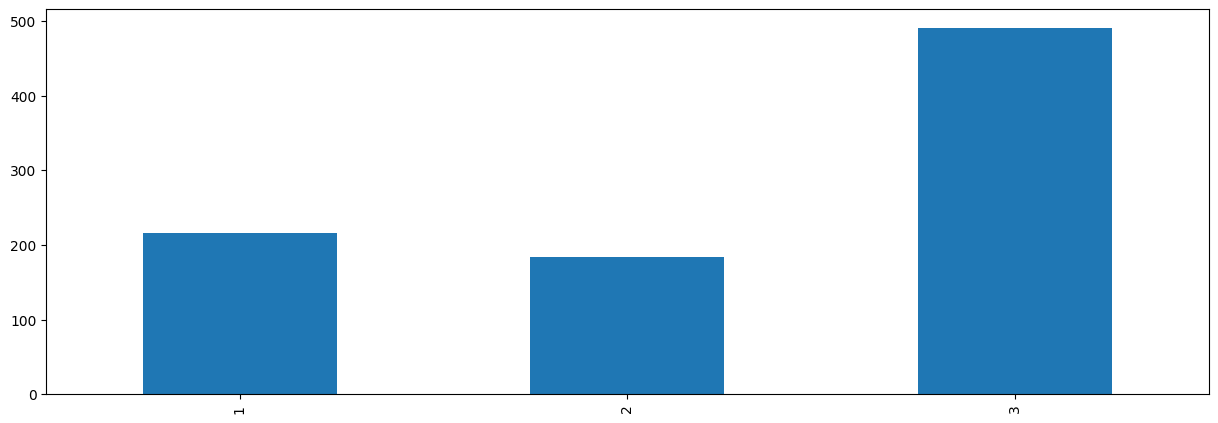

In [102]:
# gráfico de frequência
foo = df['pclass'].value_counts().sort_index()
foo.plot(kind='bar', figsize = (15, 5))

### bivariada

#### with survived

In [103]:
(df.groupby(by = 'pclass')['survived'].value_counts(normalize = True).sort_index() * 100).round(2)

pclass  survived
1       0           37.04
        1           62.96
2       0           52.72
        1           47.28
3       0           75.76
        1           24.24
Name: survived, dtype: float64

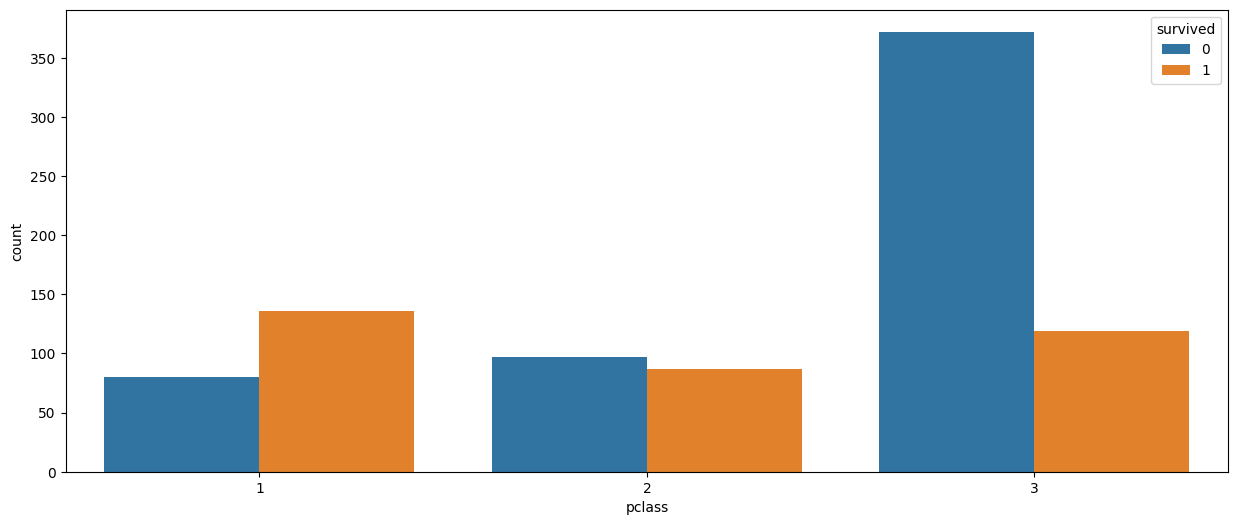

In [104]:
# correlação de classe sobrevivencia ou náo
plt.figure(figsize=(15, 6))
sns.countplot(data = df, x='pclass', hue='survived')
plt.show()

#### with sex

In [105]:
(df.groupby(by = 'pclass')['sex'].value_counts(normalize = True).sort_index() * 100).round(2)

pclass  sex   
1       female    43.52
        male      56.48
2       female    41.30
        male      58.70
3       female    29.33
        male      70.67
Name: sex, dtype: float64

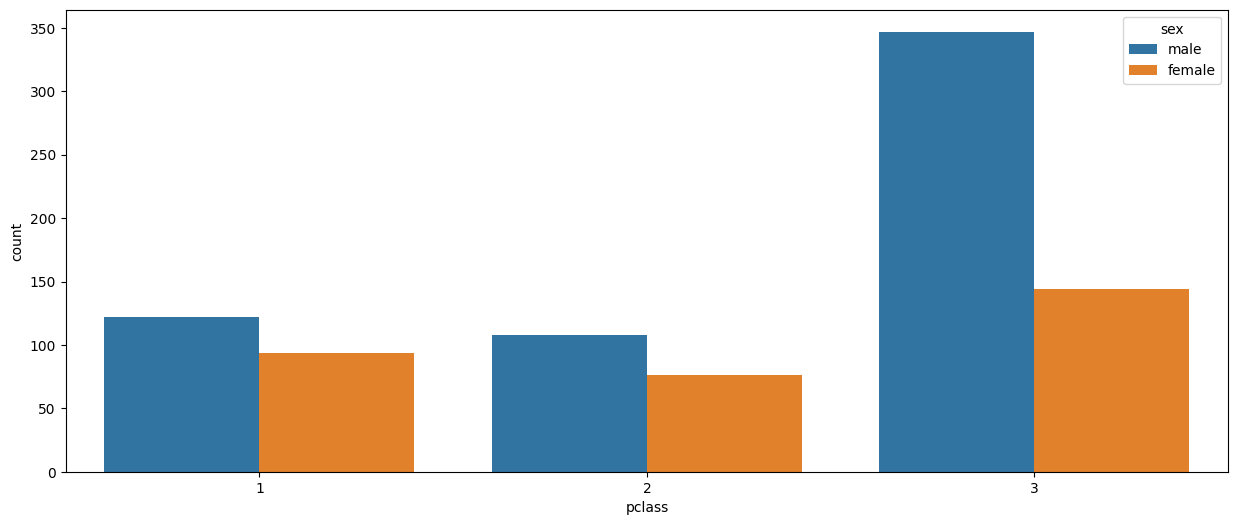

In [106]:
# correlação de classe sobrevivencia ou náo
plt.figure(figsize=(15, 6))
sns.countplot(data = df, x='pclass', hue='sex')
plt.show()

### multivariada

#### with sex and survived

In [107]:
# quantos % das mulheres soreviveu
(df.groupby(by = ['pclass', 'sex'])['survived'].value_counts(normalize=True).sort_index() * 100).round(2)[1][1]

96.81

In [108]:
# quanto % dos sobreviventes eram mulheres

## sex

### univariada

In [109]:
# frequencia absoluta
pd.DataFrame(df['sex'].value_counts().sort_index())

,sex
female,314
male,577


In [110]:
# frequencia relativa
pd.DataFrame((df['sex'].value_counts(normalize = True).sort_index() * 100).round(2))

,sex
female,35.24
male,64.76


<AxesSubplot: >

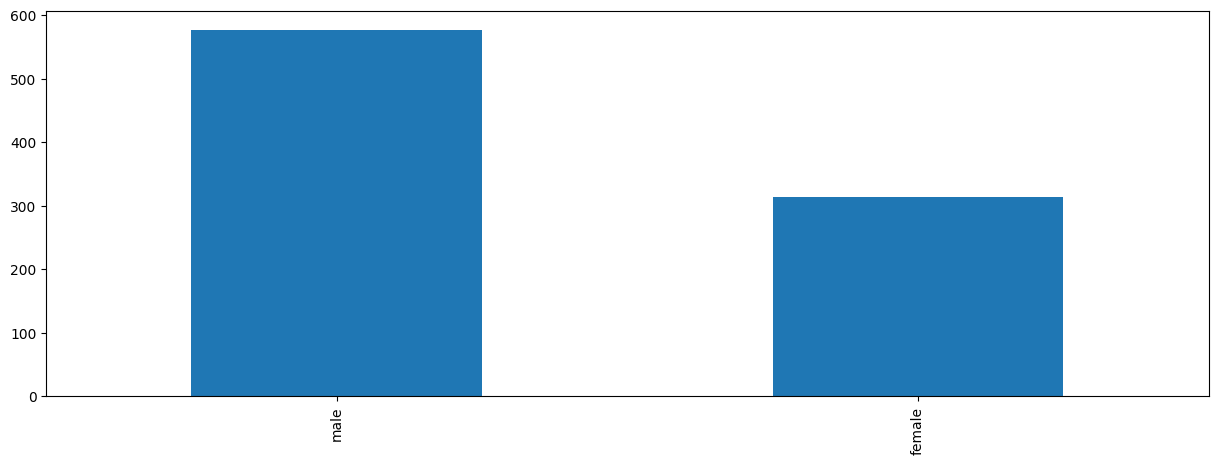

In [111]:
# gráfico de frequência
foo = df['sex'].value_counts(sort=False)
foo.plot(kind='bar', figsize = (15, 5))

### bivariada

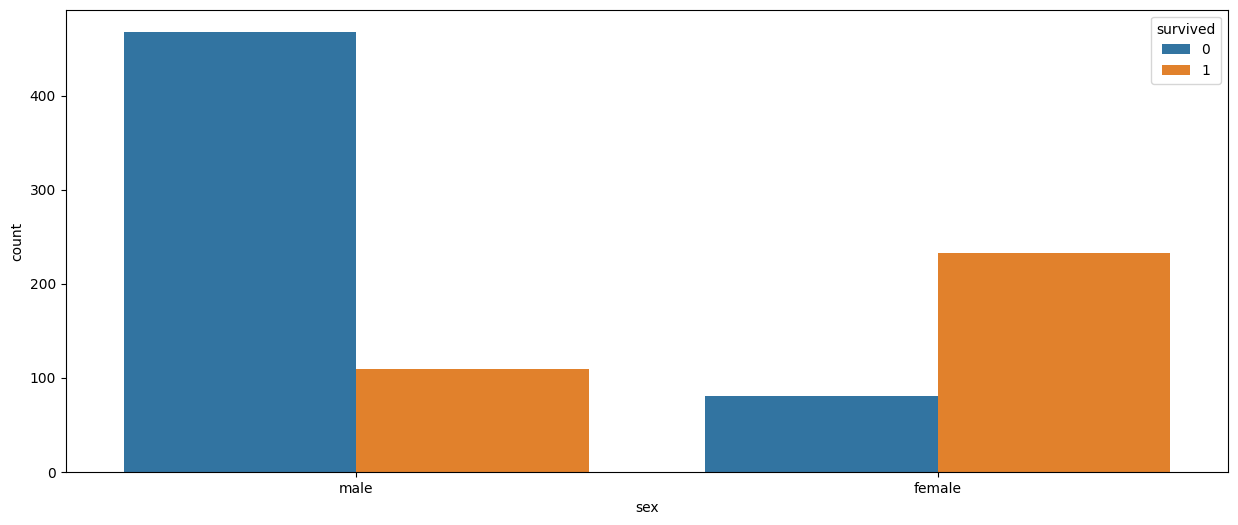

In [112]:
plt.figure(figsize=(15, 6))

sns.countplot(data=df, x='sex', hue='survived')
plt.show()

### multivariada

## age

### notes

### univariada

In [144]:
df2[['age']].describe()

,age
count,891.000000
mean,29.718485
std,13.260004
min,0.420000
25%,22.000000
50%,30.000000
75%,36.000000
max,80.000000


In [153]:
# moda
df2['age'].mode()[0]

32.0

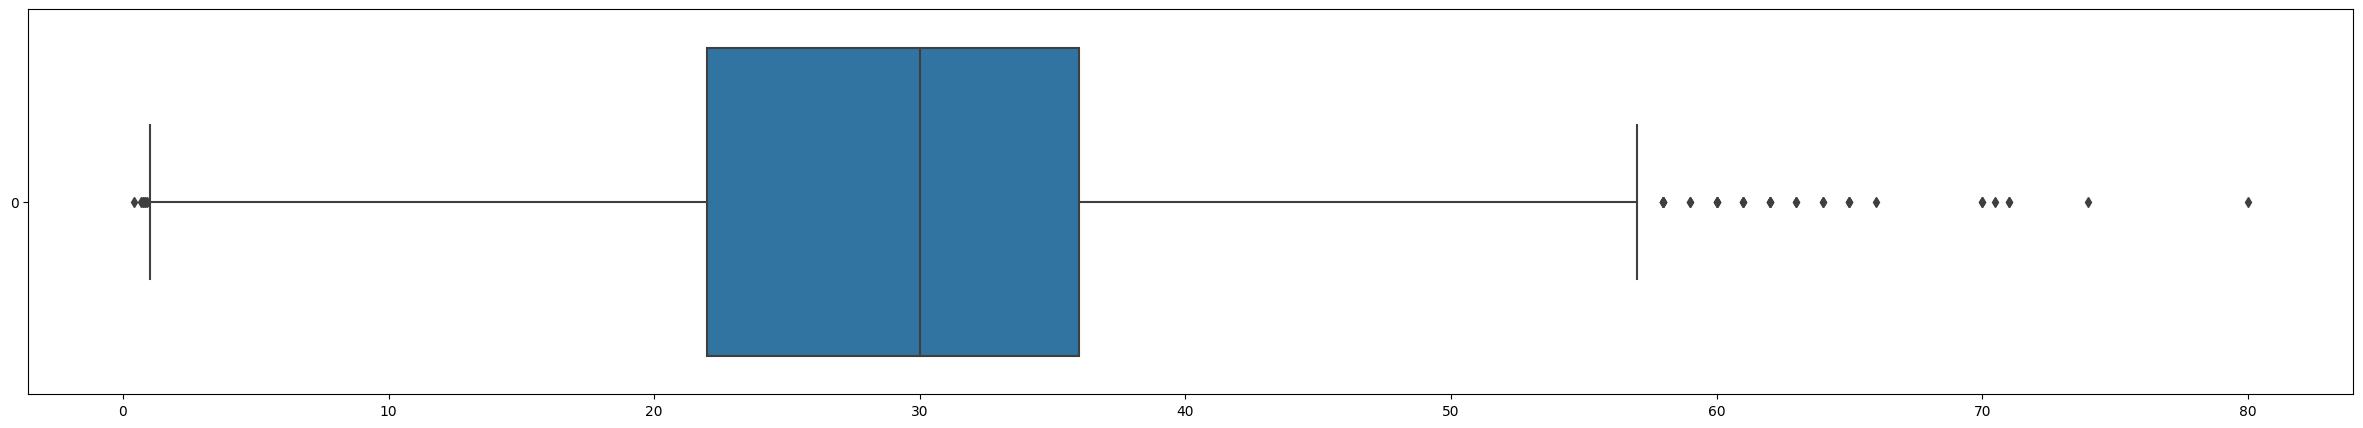

In [130]:
plt.figure(figsize=(30, 5))
sns.boxplot(df2['age'], orient='h')
plt.show()

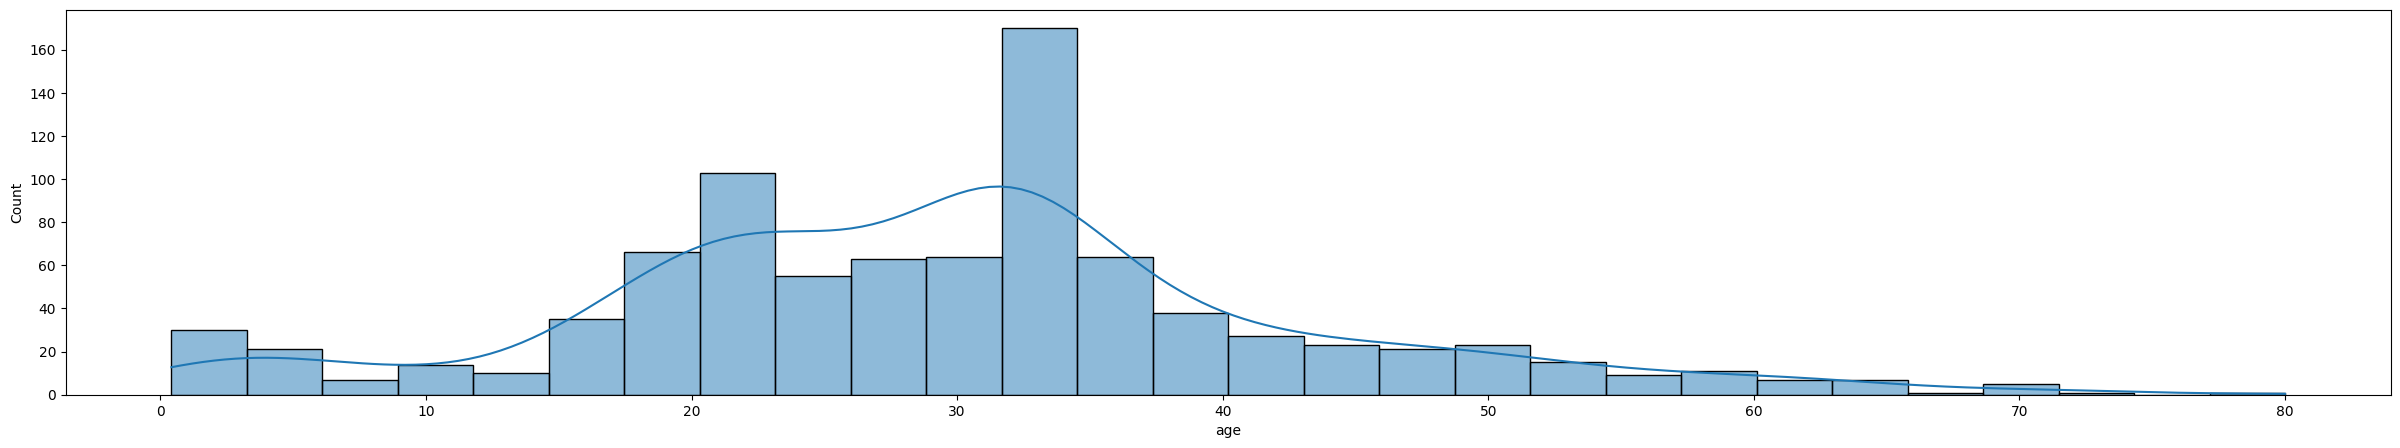

In [150]:
plt.figure(figsize=(30, 5))
sns.histplot(df2['age'], kde=True)
plt.show()

### bivariada

In [233]:
foo = pd.cut(x=df2['age'],bins=[i for i in range(0, 81, 5)]).rename('age_class')
df3 = pd.concat([df2,foo], axis = 1)
df3

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,title,age_class
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,"(20, 25]"
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,"(35, 40]"
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,"(25, 30]"
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,"(30, 35]"
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,"(30, 35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,"(25, 30]"
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,"(15, 20]"
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,"(20, 25]"
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,"(25, 30]"


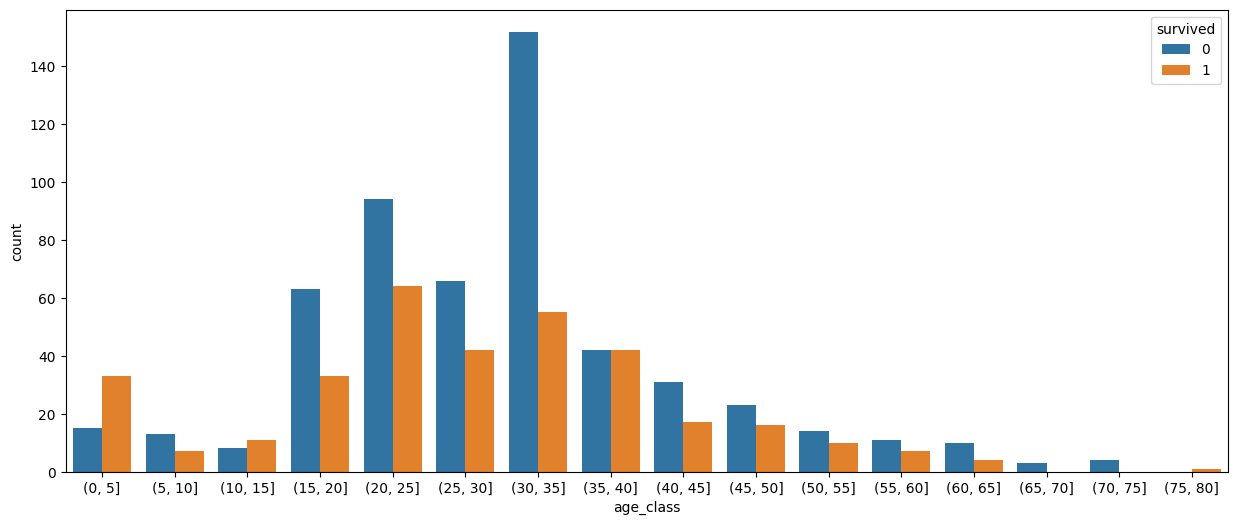

In [234]:
plt.figure(figsize=(15, 6))

sns.countplot(data=df3, x = 'age_class', hue='survived')
plt.show()

In [239]:
# coeficiente de spearman
df3['age'].corr(method = 'spearman', other=df3['survived'])

-0.06756616445494003

### multivariada